# Built-In Eccentricity Distributions

DebrisPy includes a suite of built-in eccentricity profiles, each implemented as a subclass of the general `EccentricityDistribution` class. This modular design enables clean and convenient access to different functional forms while avoiding the overhead of manually specifying complex keyword arguments.

The key advantages of these built-in profiles are:

- **Analytic Kernel Forms**: Each profile has a known analytic expression for the kernel \( \Phi(r, a) \), eliminating the need for numerical integration during kernel evaluation. This significantly improves both accuracy and computational efficiency.

- **Pre-Normalised Distributions**: These profiles are normalised by construction, meaning that no numerical normalisation or gridding is required. Instead, the entire distribution is defined through closed-form expressions encapsulated within the class.

- **Fully Compatible with the Pipeline**: Although the user may optionally provide `num_e_points` and `num_a_points` during initialisation, these parameters are only used for visualisation and do **not** affect the pipeline or the computed results in any way.

Each built-in profile inherits all general methods from the `EccentricityDistribution` base class, including the ability to plot the distribution or evaluate it at arbitrary points. The following sections describe each built-in profile in detail, including how to initialise them and how to visualise their structure.


## Rayleigh Distribution

The *Rayleigh* eccentricity distribution is a commonly used form for modelling debris discs. Its normalised probability density function is given by:

$$
\psi_e(e, a) = \frac{e}{\sigma(a)^2 \left[1 - \exp\left(-\frac{1}{2\sigma(a)^2}\right)\right]} \exp\left(-\frac{e^2}{2\sigma(a)^2}\right)
$$

This distribution is implemented in the `RayleighEccentricity` class.

### Defining the $\sigma(a)$ Profile

The width of the distribution, $\sigma(a)$, controls the spread in eccentricity and must be specified by the user. Two options are available:

1. **Built-in power-law profile**:

   $$
   \sigma(a) = \sigma_0 \left(\frac{a_{\min}}{a}\right)^p
   $$

   - The normalisation $\sigma_0$ is passed via the `sigma0` argument.
   - The power-law index $p$ is passed via the `power` argument.

2. **Custom sigma function**:

   Users may also provide an arbitrary functional form for $\sigma(a)$ via the `sigma_func` argument, which must be a callable accepting a scalar or array of semi-major axis values.

After initialisation, the distribution can be visualised in 2D using the `plot()` method (see next sections for full description of method).

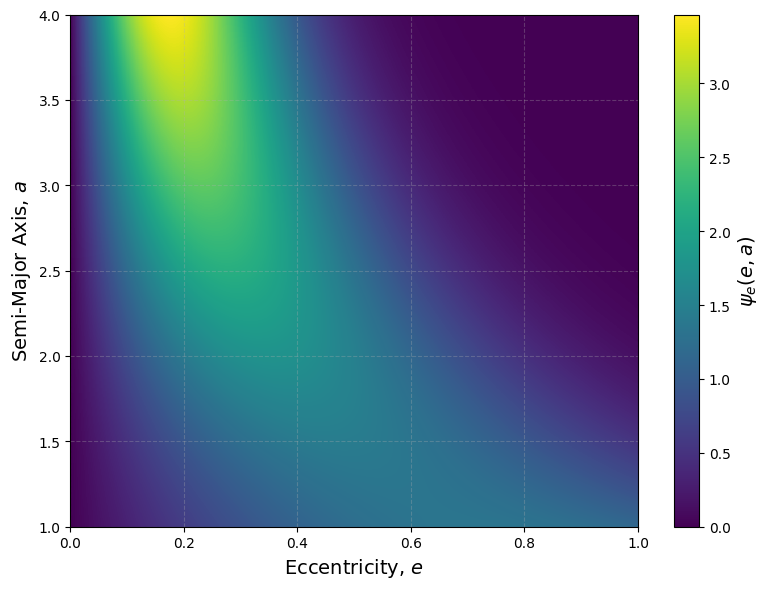

In [1]:
import numpy as np 
from debrispy import RayleighEccentricity

ecc = RayleighEccentricity(a_min=1, a_max=4, sigma0=0.7, power=1)
ecc.plot()

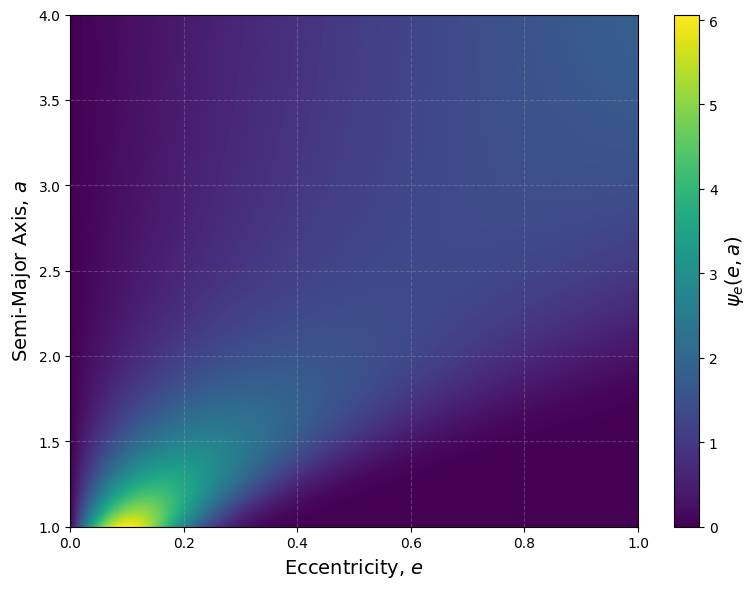

In [2]:
def sigma_func(a):
    return 0.1*a**2

ecc = RayleighEccentricity(a_min=1, a_max=4, sigma_func=sigma_func)
ecc.plot()

## Additional Eccentricity Distributions

In addition to the Rayleigh distribution, DebrisPy supports a range of other eccentricity distributions. These are named according to the characteristic shape of the ASD, $\bar{\Sigma}(r)$, that they produce in the limit of a geometrically thin disc (i.e. when $\Sigma_a(a)$ approaches a Dirac delta function).

All of these additional distributions share a common structure: they depend on a shape-controlling parameter $\lambda(a)$, which sets the upper bound on allowable eccentricities. This function must be specified using the `lam` argument, and may be provided either as:

- A constant float (for a uniform envelope), or  
- A callable function of semi-major axis \( a \) (to allow for spatial variation)

Each distribution enforces internal checks to ensure that $0 < \lambda(a) \leq 1$ across the domain (this is to ensure that $e(a)$ remains physical).

### "Top-Hat" Distribution

The "top-hat" eccentricity distribution is defined as,

$$
\psi_e(e, a) = \frac{1}{\lambda(a)} \cdot \frac{e}{\sqrt{\lambda(a)^2 - e^2}}, \quad \text{for } e < \lambda(a)
$$

This distribution is supported via the `TopHatEccentricity` class.


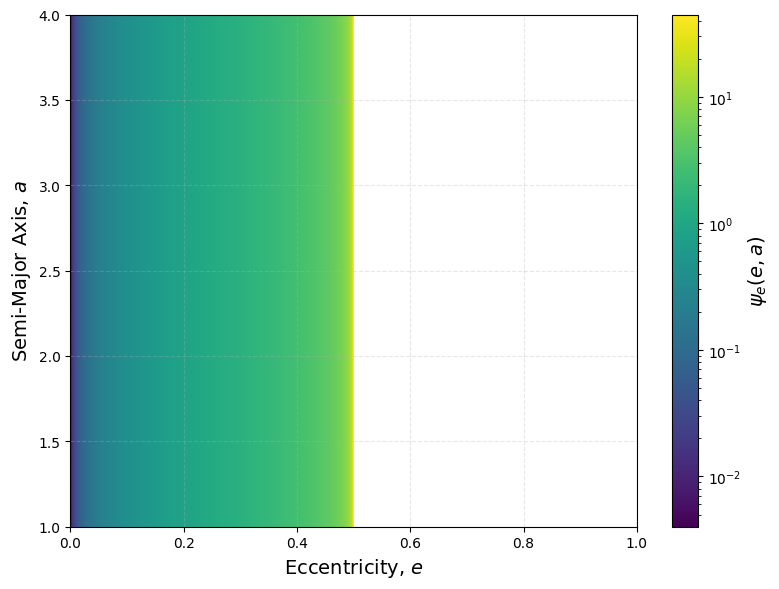

In [3]:
from debrispy import TopHatEccentricity
top_hat = TopHatEccentricity(a_min=1, a_max=4, lam = 0.5)

# Plotting 2D eccentricity distribution in log-space
top_hat.plot(log = True)        

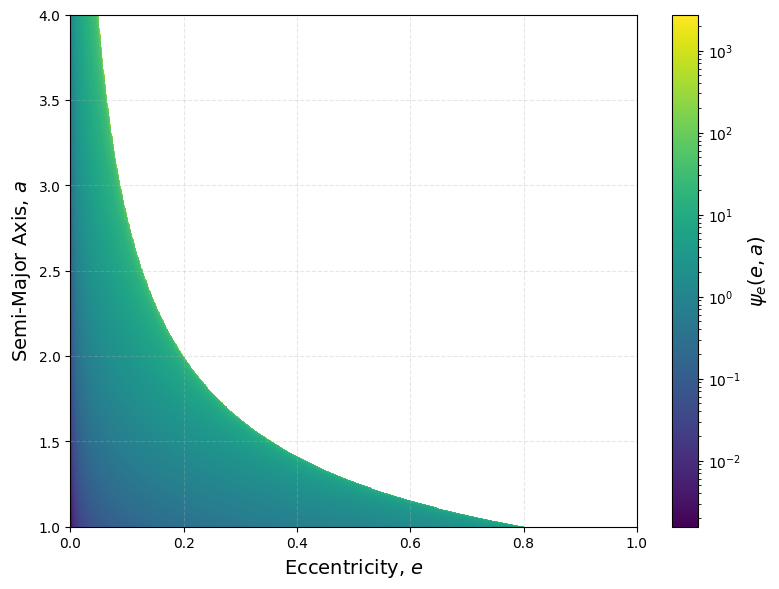

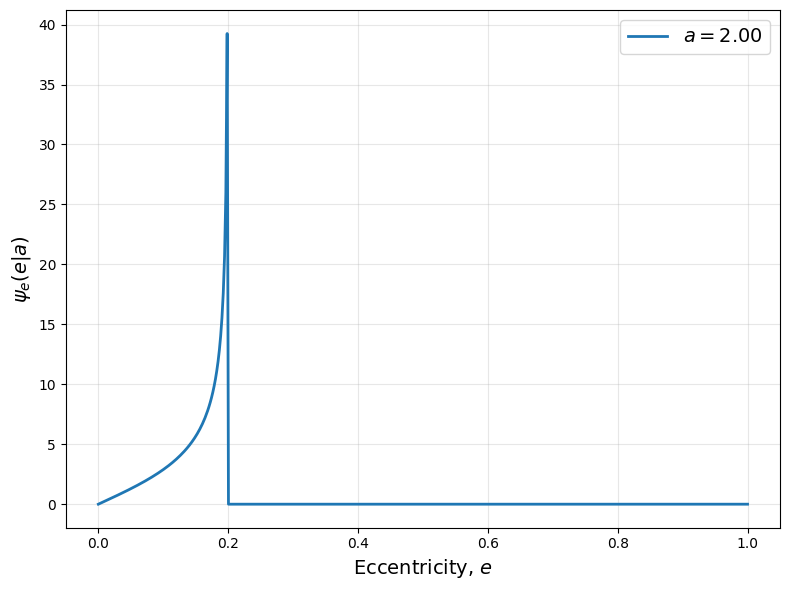

In [4]:
def lam_func(a):
    return 0.8*(1/a)**2

top_hat = TopHatEccentricity(a_min=1, a_max=4, lam = lam_func)
top_hat.plot(log = True)
top_hat.plot_slice(fix_a=2)

### "Triangular" Distribution

The "triangular" eccentricity distribution is defined as,

$$
\psi_e(e, a) = \frac{2e}{\lambda(a^2)} \log{\frac{\lambda(a) + \sqrt{\lambda(a)^2 - e^2}}{e}}, \quad \text{for } e < \lambda(a)
$$

This distribution is supported via the `TriangularEccentricity` class.


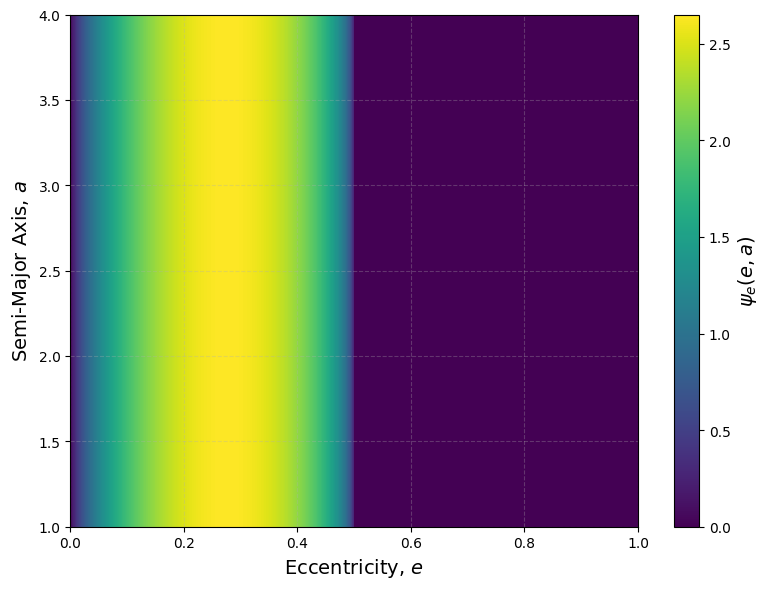

In [5]:
from debrispy import TriangularEccentricity

tri = TriangularEccentricity(a_min=1, a_max=4, lam = 0.5)
tri.plot()

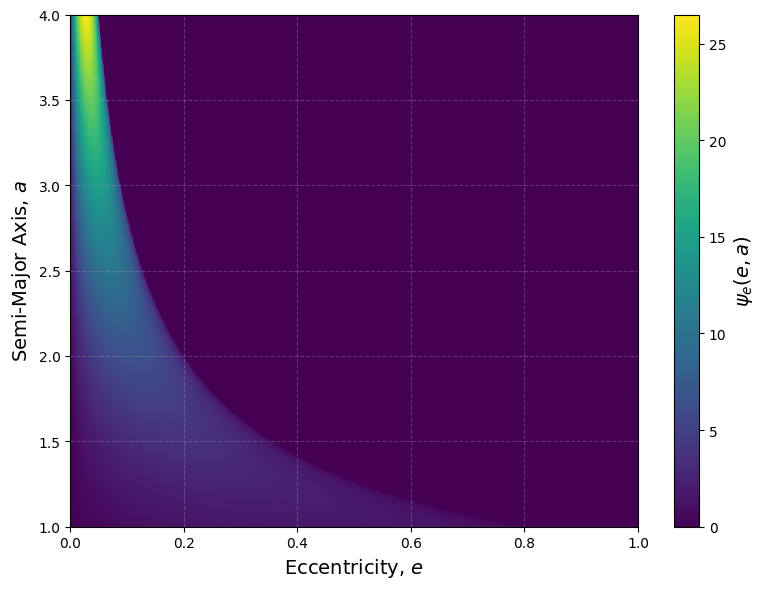

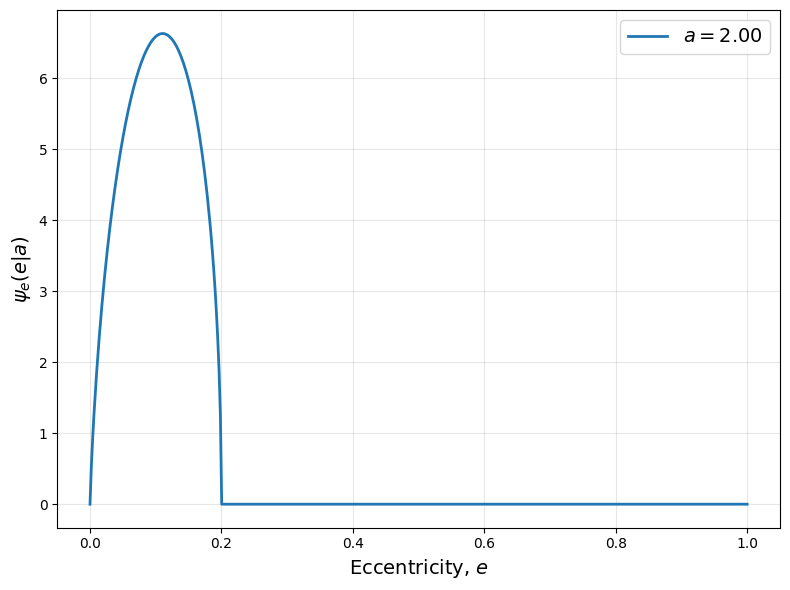

In [6]:
tri = TriangularEccentricity(a_min=1, a_max=4, lam = lam_func)

tri.plot()
tri.plot_slice(fix_a=2)

### "Power-Law" Distribution

The *power-law* eccentricity distribution is defined as:

$$
\psi_e(e, a) = (2\zeta + 1)\, \lambda(a)^{-(2\zeta + 1)}\, e\, \left[\lambda(a)^2 - e^2\right]^{\zeta - 1/2}, \quad \text{for } e < \lambda(a)
$$

This distribution is implemented via the `PowerLawEccentricity` class. In addition to `lam`, this distribution requires the user to specify $\zeta$ (steepness of the distribution) via the `zeta` keyword argument.

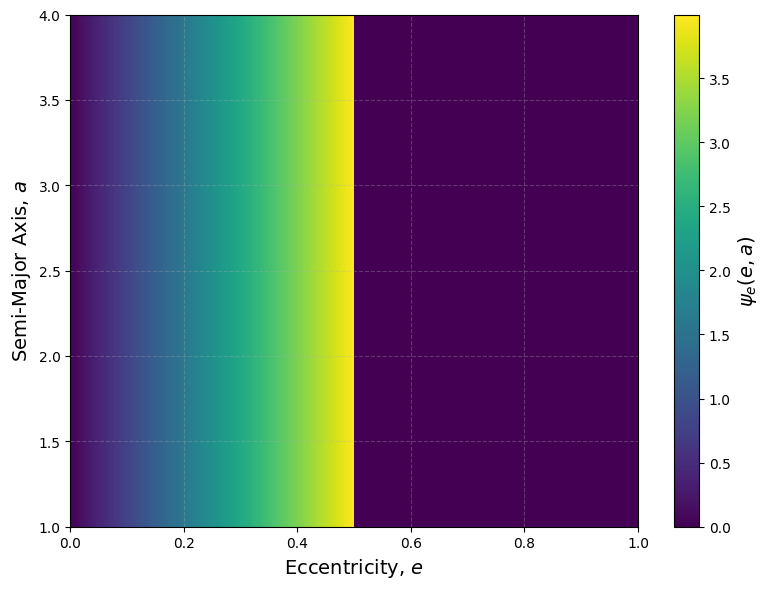

In [7]:
from debrispy import PowerLawEccentricity

power_law = PowerLawEccentricity(a_min=1, a_max=4, lam=0.5, zeta = 0.5)
power_law.plot()

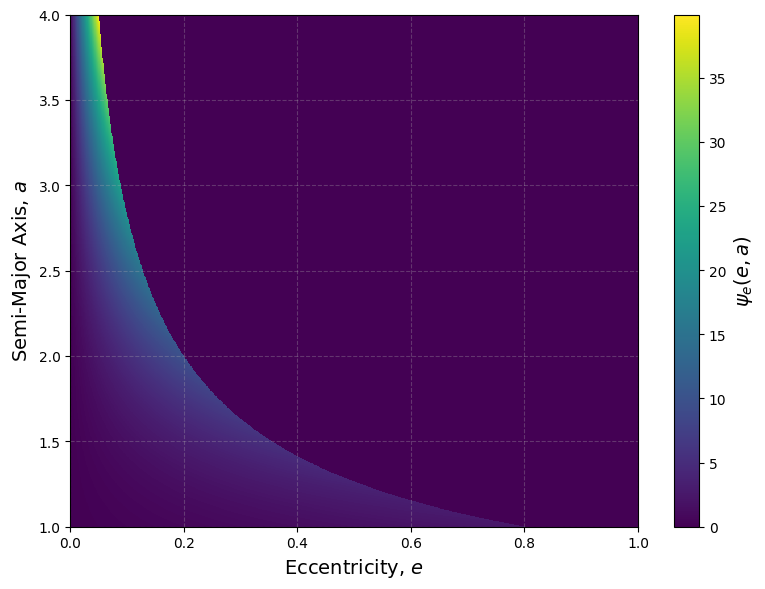

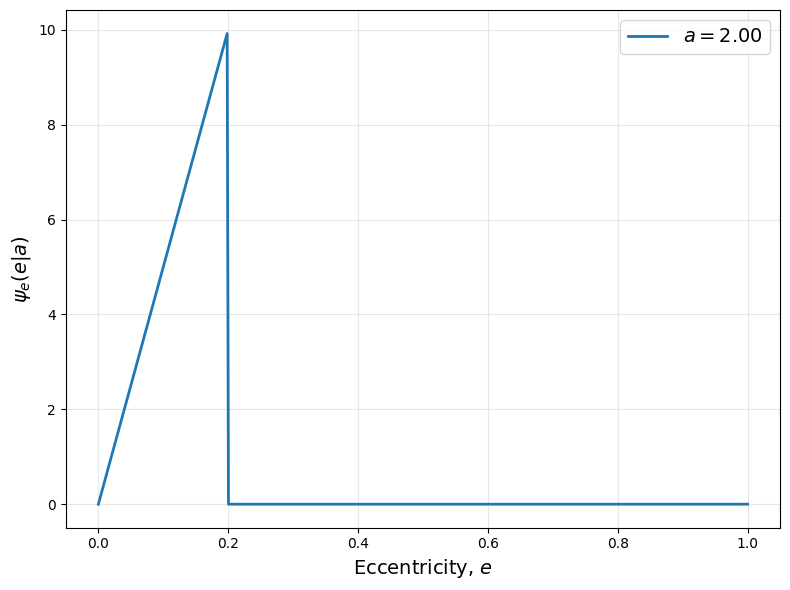

In [8]:
power_law = PowerLawEccentricity(a_min=1, a_max=4, lam=lam_func, zeta = 0.5)

power_law.plot()
power_law.plot_slice(fix_a=2)

### "Truncated Gaussian" Distribution

The "truncated Gaussian" eccentricity distribution is defined as:

$$
\psi_e(e, a) = \sqrt{\frac{2}{\pi}}\, C\, e \left[ \frac{\exp{\left(-\frac{e^2}{2\sigma_\kappa^2}\right)}}{\sigma_\kappa} \cdot \text{erf} \left( \sqrt{\frac{\lambda(a)^2 - e^2}{2 \sigma_\kappa^2}} \right) + \sqrt{\frac{2}{\pi}} \cdot \frac{\exp{\left(-\frac{\lambda(a)^2}{2\sigma_\kappa^2}\right)}}{\sqrt{\lambda(a)^2 - e^2}} \right],
$$

for  $e < \lambda(a)$, where the normalisation factor, $C$, is given by:

$$
C = \sqrt{\frac{\pi}{2}} \cdot \frac{1}{\sigma_\kappa} \left[ \text{erf} \left( \frac{\lambda(a)}{\sqrt{2}\sigma_\kappa} \right) \right]^{-1}
$$

This distribution is implemented via the `TruncGaussEccentricity` class.

To use this distribution, the user must specify:

- `sigma`: The width parameter $\sigma_\kappa$, which must be strictly positive. This can be provided either as:
  - A constant float (e.g., `sigma=0.05`), or
  - A callable function of semi-major axis, $a$.

- `lam`: The upper envelope function, $\lambda(a)$, which restricts the allowed eccentricities. As with other profiles, this can be a float or callable, and must satisfy $0 < \lambda(a) \leq 1$.

The distribution is automatically normalised and internally validated.

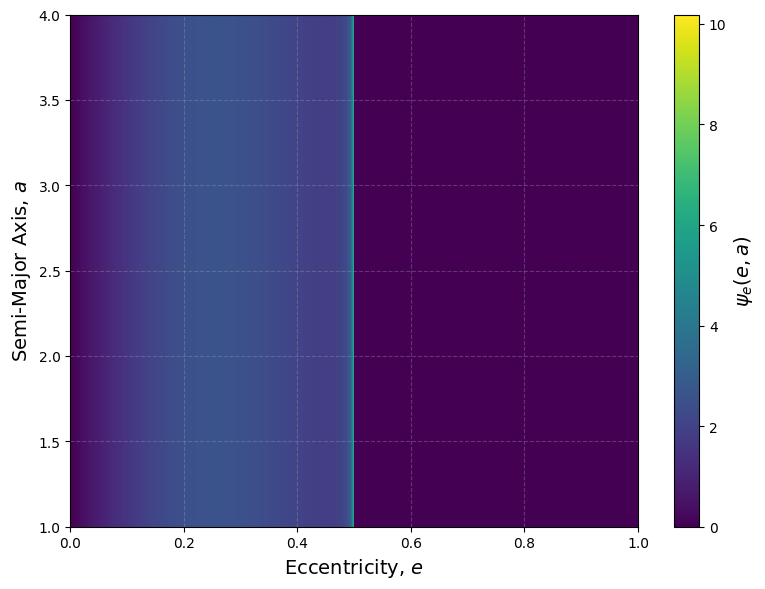

In [9]:
from debrispy import TruncGaussEccentricity

trunc_gauss = TruncGaussEccentricity(a_min=1, a_max=4, lam=0.5, sigma = 0.25)
trunc_gauss.plot()

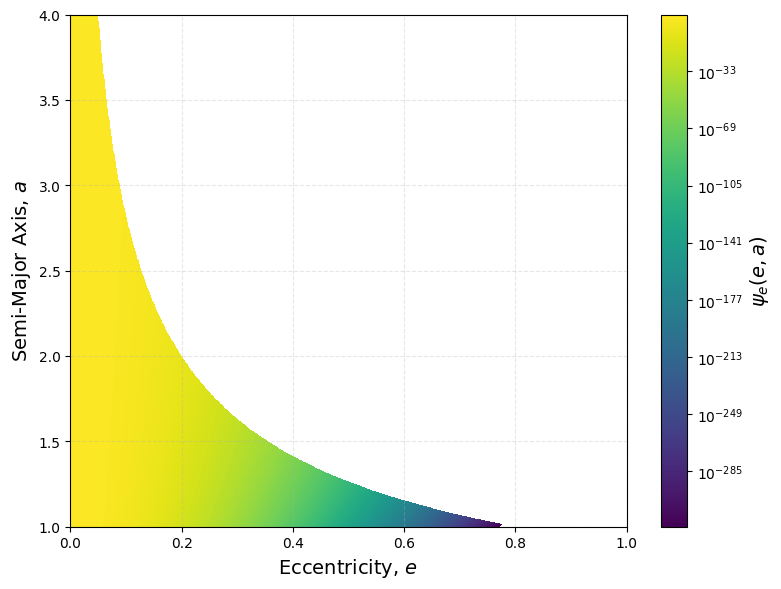

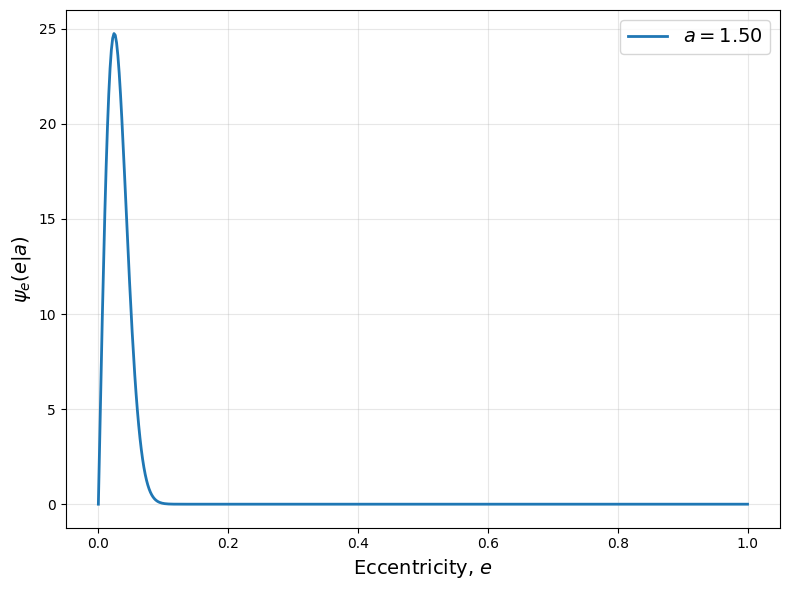

In [10]:
def sig_func(a):
    return 0.02*a**0.5

trunc_gauss = TruncGaussEccentricity(a_min=1, a_max=4, lam=lam_func, sigma = sig_func)
trunc_gauss.plot(log = True)
trunc_gauss.plot_slice(fix_a=1.5)

## Common Interface for Built-in Distributions

All built-in eccentricity distributions in **DebrisPy** (e.g., Rayleigh, PowerLaw, TruncatedGaussian) inherit from a common base class and hence have a unified interface. This allows for easy querying, visualisation, and diagnostic access to the distribution function $\psi_e(e, a)$.

### Accessing the Distribution Values

To evaluate the distribution at specific values of eccentricity, $e$, and semi-major axis, $a$, one can use the `distribution()` method, which returns the $\psi_e(e, a)$ values evaluated at the chosen points.

Both `e` and `a` can be scalars or NumPy arrays. If arrays are passed, broadcasting is *automatically handled* to return the corresponding grid of values. 

**Note:** When both $e$ and $a$ are scalars, the method returns a NumPy array of shape (1,) rather than a pure float. This is for consistency with the vectorised interface.

In [11]:
e = 0.5
a = 2

print(ecc.distribution(e, a))

[1.49648]


In [12]:
e = np.array([0.5, 0.7])
a = 2

print(ecc.distribution(e, a))

[1.49648    0.98964194]


In [13]:
e = np.array([0.5, 0.7])
a = np.array([2, 3])

print(ecc.distribution(e, a))

[[1.49648    1.14854331]
 [0.98964194 1.38654985]]


### 2D Visualisation

The user can visualise the 2D $\psi_e(e, a)$ distribution as a colourmap, using the `plot()` method.

Although the built-in eccentricity distributions are analytically normalised and therefore do not require any gridding for the pipeline, we still construct a 2D grid over eccentricity and semi-major axis values for visualisation purposes. This allows the user to explore the distribution using heatmaps or scatter plots.

The grid resolution is controlled by two optional arguments which are set when initialising the class:

- `num_e_points`: Number of eccentricity grid points (default: 1000)
- `num_a_points`: Number of semi-major axis grid points (default: 1000)

These define the resolution of the sampled distribution used *only for plotting*. They do **not** affect the kernel computation or any downstream steps in the modelling pipeline.

Supported keyword arguments include:


| Argument                   | Description                                                                 |
|----------------------------|-----------------------------------------------------------------------------|
| `log=True`                 | Enables a logarithmic colour scale.                                        |
| `points=True`              | Visualises the distribution as scatter points rather than a continuous map. |
| `vmin`, `vmax`             | Manually sets the colour scale limits.                                     |
| `save=True`, `filename=…`  | Saves the plot to the specified filename instead of displaying it.         |
| `cmap`                     | The colourmap to use when plotting. (Default: Viridis)                            |

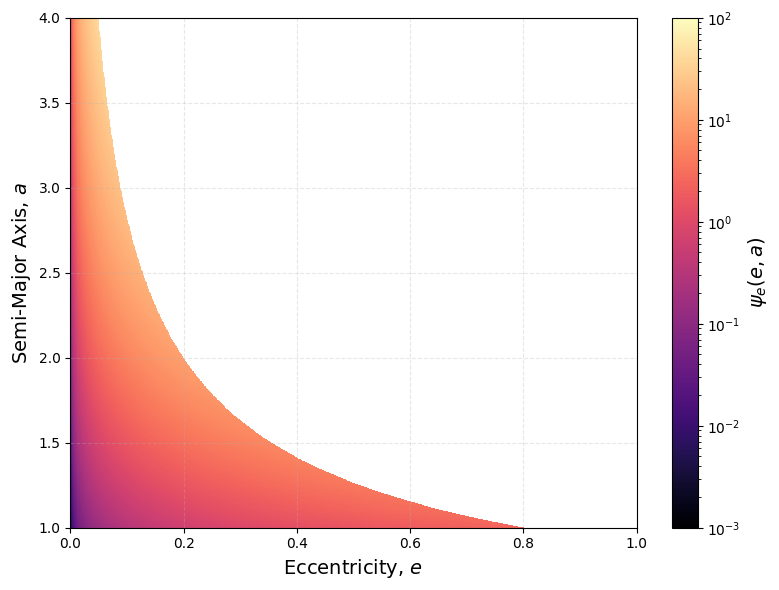

In [14]:
# Example of a power-law distribution
power_law = PowerLawEccentricity(a_min=1, a_max=4, lam=lam_func, zeta = 0.5)

power_law.plot(cmap = 'magma', log = True, vmin = 1e-3, vmax = 1e2)

### 1D "Slice" Visualisation

The `plot_slice()` method provides a convenient way to visualise **1D slices** of the 2D eccentricity distribution by fixing either the eccentricity or the semi-major axis.

This is particularly useful for understanding the distribution shape at a specific orbital distance or eccentricity.

**Usage Options:**
- To plot $\psi_e(e)$ at a fixed semi-major axis $a$, use the `fix_a` keyword.
- To plot $\psi_e(a)$ at a fixed eccentricity $e$, use the `fix_e` keyword.
- **Exactly one** of `fix_a` or `fix_e` must be supplied.

**Default Behaviour:**
- 500 points are sampled by default (`num_points=500`).
- A new figure is created unless an existing `ax` is passed.
- Axis labels, a legend, and gridlines are added automatically.
- The plot is shown by default (`show=True`). To save instead, use `save=True` and specify a `filename`.

**Customisation:**
The plot accepts additional `matplotlib.pyplot.plot()` keyword arguments. Common options include:

| Argument     | Description                                  |
|--------------|----------------------------------------------|
| `color`      | Line colour                                  |
| `linestyle`  | Line style (`'-'`, `'--'`, `':'`, etc.)      |
| `marker`     | Marker style for points                      |
| `linewidth`  | Thickness of the line                        |
| `label`      | Custom legend label                          |

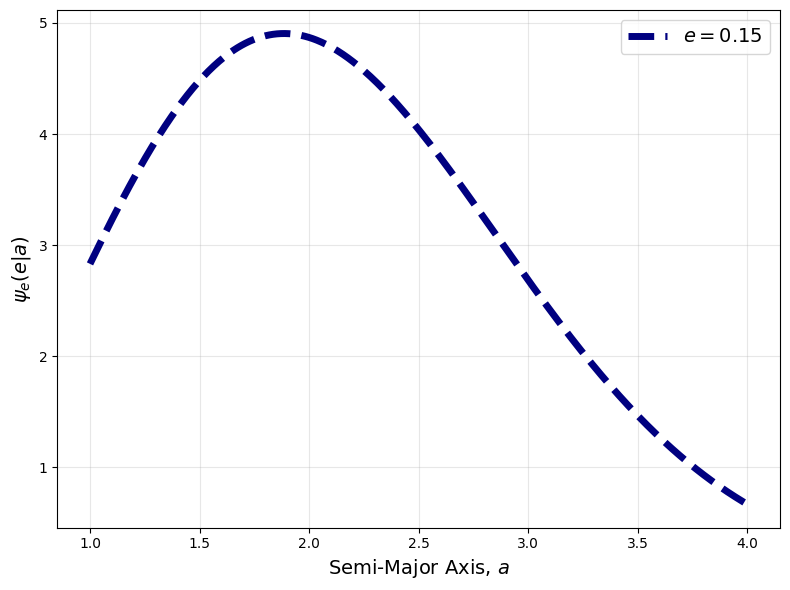

In [15]:
ecc = RayleighEccentricity(a_min=1, a_max=4, sigma0=0.2, power=1)
ecc.plot_slice(fix_e=0.15, color='navy', linewidth=5, linestyle='--')

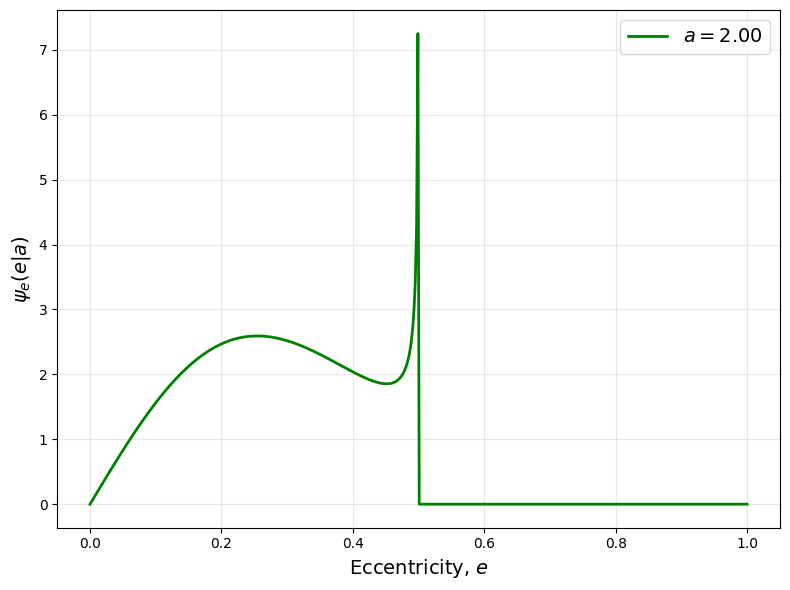

In [16]:
trunc_gauss = TruncGaussEccentricity(a_min=1, a_max=4, lam=0.5, sigma = 0.25)
trunc_gauss.plot_slice(fix_a=2, color='green', linewidth=2, linestyle='-')